# Frequency Sweep 5000–9000 MHz — tprocv2

Sweeps a CW pulse from 5000 to 9000 MHz and plots magnitude vs frequency for two setups:

- **Setup 1** (Gen 0 / RO 0): `axis_signal_gen_v6` → 5-6 GHz balun → **VLF-7200+ LPF** → 5-6 GHz balun → ADC
- **Setup 2** (Gen 3 / RO 1): `axis_sg_mux8_v1` → 5-6 GHz balun → 5-6 GHz balun → ADC *(no filter)*

Both setups run sequentially at each frequency point and results are plotted side by side.

---

## Generator differences: `axis_signal_gen_v6` vs `axis_sg_mux8_v1`

| Feature | `axis_signal_gen_v6` (Gen 0) | `axis_sg_mux8_v1` (Gen 3) |
|---|---|---|
| Purpose | Single-tone generator | Up to 8 simultaneous tones (multiplexed readout) |
| Frequency set in | `add_pulse(freq=...)` | `declare_gen(mux_freqs=[...])` at init time |
| Gain set in | `add_pulse(gain=...)` | `declare_gen(mux_gains=[...])` at init time |
| Tone selection | Implicit (one tone) | `add_pulse(mask=[0, 1, ...])` selects which tones play |
| Phase control | `add_pulse(phase=...)` | Not per-tone in const style |
| Frequency change | Update pulse params | Requires new program instance |

For this single-tone sweep, the mux8 generator works identically to the standard generator — we just declare one frequency in `mux_freqs` and use `mask=[0]`. Since we create a new program for each frequency point anyway, the init-time frequency constraint is not a limitation.

In [1]:
from qick import *
from qick.asm_v2 import AveragerProgramV2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline

In [2]:
# Initialize QICK (tprocv2 firmware)
soc = QickSoc(bitfile="../../qick/firmware/projects/2024-09-03_216_tprovc2r21_demo/qick_216.bit")
soccfg = soc
print(soccfg)

QICK running on ZCU216, software version 0.2.396

Firmware configuration (built Tue Sep  3 12:55:04 2024):

	Global clocks (MHz): tProc dispatcher timing 614.400, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 2], [DAC tile 3], [ADC tile 2]

	5 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 16384 complex samples (1.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or XM655 DAC port 8
	1:	axis_sg_int4_v2 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 4096 complex samples (9.524 us)
		32-bit DDS, range=1720.320 MHz
		DAC tile 3, blk 0 is 0_231 on JHC3, or XM655 DAC port 12
	2:	axis_sg_int4_v2 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 4096 complex samples (9.524 us)
		32-bit DDS, range=1720.320 MHz
		DAC tile 3, blk 1 is 1_231 on JHC4, or XM655 DAC port 13
	3:	axis_sg_mux8_v1 - fs=9830.400 Msps, fabric=614.400 MHz
		32-bit DDS, range=9830.400 

In [3]:
# ── Channel assignments ────────────────────────────────────────────────────────
#
# Setup 1: axis_signal_gen_v6 — standard single-tone generator
#   DAC tile 2, blk 0 → JHC3 → XM655 DAC port 8
#   → 5-6 GHz balun → VLF-7200+ LPF → 5-6 GHz balun
#   → ADC tile 2, blk 0 → JHC7 → XM655 ADC port 4
GEN_CH_1 = 0
RO_CH_1  = 0

# Setup 2: axis_sg_mux8_v1 — multiplexed generator (used here as single tone)
#   DAC tile 2, blk 2 → JHC3 → XM655 DAC port 10
#   → 5-6 GHz balun → 5-6 GHz balun (no filter)
#   → ADC tile 2, blk 1 → JHC8 → XM655 ADC port 5
GEN_CH_2 = 3
RO_CH_2  = 6 #1 # Use 6 for same decimation

print(f"Setup 1 — Gen {GEN_CH_1} (axis_signal_gen_v6) → RO {RO_CH_1}  [with LPF]")
print(f"Setup 2 — Gen {GEN_CH_2} (axis_sg_mux8_v1)   → RO {RO_CH_2}  [no filter]")

Setup 1 — Gen 0 (axis_signal_gen_v6) → RO 0  [with LPF]
Setup 2 — Gen 3 (axis_sg_mux8_v1)   → RO 6  [no filter]


## Program definitions

Two separate program classes are used because the two generator types have different APIs.

Both readout channels on the tprocv2 firmware are **dynamic** (`axis_dyn_readout_v1` and `axis_readout_v3`), meaning the DDC frequency cannot be set in `declare_readout` — it must be sent at runtime via `send_readoutconfig`.

If you see oscillating I/Q with a flat magnitude after running, the DDC frequency matching is slightly off. See the diagnostic cell at the bottom for how to measure and correct the beat frequency.

In [4]:
# ── Setup 1: axis_signal_gen_v6 (standard generator) ──────────────────────────
class Setup1Program(AveragerProgramV2):
    """
    Standard axis_signal_gen_v6 generator.
    - Frequency set in add_pulse(freq=...)
    - Gain normalized to -1.0 to 1.0
    - DDC configured via add_readoutconfig + send_readoutconfig
    """
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg["res_ch"], nqz=cfg["nqz"])
        self.declare_readout(ch=cfg["ro_chs"][0], length=cfg["readout_length"])

        # DDC frequency for dynamic readout — must match the ADC alias of pulse_freq
        self.add_readoutconfig(
            ch=cfg["ro_chs"][0],
            name="ro_cfg",
            freq=cfg["pulse_freq"],
            gen_ch=cfg["res_ch"]   # tells QICK to compute the ADC alias automatically
        )

        self.add_pulse(
            ch=cfg["res_ch"],
            name="sweep_pulse",
            style="const",
            freq=cfg["pulse_freq"],
            phase=cfg["res_phase"],
            gain=cfg["pulse_gain"],
            length=cfg["length"]
        )
        self.delay_auto(0.5)  # let pulse config settle (replaces synci)

    def _body(self, cfg):
        # Send DDC config to dynamic readout via tProc
        self.send_readoutconfig(ch=cfg["ro_chs"][0], name="ro_cfg", t=0)
        self.pulse(ch=cfg["res_ch"], name="sweep_pulse", t=0)
        self.trigger(ros=[cfg["ro_chs"][0]], t=cfg["adc_trig_offset"])
        self.delay_auto(cfg["relax_delay"])

In [5]:
# ── Setup 2: axis_sg_mux8_v1 (multiplexed generator, used as single tone) ─────
class Setup2Program(AveragerProgramV2):
    """
    Mux8 generator used in single-tone mode.

    Key differences from standard generator:
    - mux_freqs and mux_gains are lists declared at init, not per-pulse
    - add_pulse uses mask=[0] to select only the first tone
    - No freq/phase/gain arguments in add_pulse
    - Changing frequency requires a new program instance (which we do anyway)
    """
    def _initialize(self, cfg):
        # For mux8: frequencies and gains declared here, not in add_pulse
        self.declare_gen(
            ch=cfg["res_ch"],
            nqz=cfg["nqz"],
            mux_freqs=[cfg["pulse_freq"]],   # list: up to 8 tones
            mux_gains=[cfg["pulse_gain"]],   # matching list of gains
        )
        self.declare_readout(ch=cfg["ro_chs"][0], length=cfg["readout_length"])

        self.add_readoutconfig(
            ch=cfg["ro_chs"][0],
            name="ro_cfg",
            freq=cfg["pulse_freq"],
            gen_ch=cfg["res_ch"]
        )

        # mask=[0] plays only tone 0 from mux_freqs
        # No freq/phase/gain here — those live in declare_gen for mux8
        self.add_pulse(
            ch=cfg["res_ch"],
            name="sweep_pulse",
            style="const",
            mask=[0],
            length=cfg["length"]
        )
        self.delay_auto(0.5)

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg["ro_chs"][0], name="ro_cfg", t=0)
        self.pulse(ch=cfg["res_ch"], name="sweep_pulse", t=0)
        self.trigger(ros=[cfg["ro_chs"][0]], t=cfg["adc_trig_offset"])
        self.delay_auto(cfg["relax_delay"])

In [6]:
class Setup2ProgramStatic(AveragerProgramV2):
    """
    For static (PYNQ-configured) readouts like axis_pfb_readout_v3 (ch 2-5)
    and axis_readout_v2 (ch 6).
    freq goes in declare_readout directly — no add_readoutconfig needed.
    """
    def _initialize(self, cfg):
        self.declare_gen(
            ch=cfg["res_ch"],
            nqz=cfg["nqz"],
            mux_freqs=[cfg["pulse_freq"]],
            mux_gains=[cfg["pulse_gain"]],
        )
        # For static readouts: freq and gen_ch go here directly
        self.declare_readout(
            ch=cfg["ro_chs"][0],
            length=cfg["readout_length"],
            freq=cfg["pulse_freq"],      # ← set here for static
            gen_ch=cfg["res_ch"]         # ← ensures DDC alias matching
        )
        self.add_pulse(
            ch=cfg["res_ch"],
            name="sweep_pulse",
            style="const",
            mask=[0],
            length=cfg["length"]
        )
        self.delay_auto(0.5)

    def _body(self, cfg):
        # No send_readoutconfig needed for static readouts
        self.pulse(ch=cfg["res_ch"], name="sweep_pulse", t=0)
        self.trigger(ros=[cfg["ro_chs"][0]], t=cfg["adc_trig_offset"])
        self.delay_auto(cfg["relax_delay"])

## Single-frequency sanity check

Before running the full sweep, verify both programs work at 7319 MHz.
You should see a non-zero magnitude for both setups (Setup 1 will be weaker due to the LPF).
If I and Q oscillate with flat magnitude, the DDC is mismatched — see the diagnostic cell below.

In [7]:
# ── Sanity check at 7319 MHz ───────────────────────────────────────────────────
TEST_FREQ = 7319  # MHz

# Units for tprocv2: lengths in µs, gain normalized -1.0 to 1.0
test_config_1 = {
    "res_ch":    GEN_CH_1,
    "ro_chs":    [RO_CH_1],
    "reps":      200,
    "relax_delay": 1.0,
    "res_phase": 0,
    "length":    soccfg.cycles2us(100, gen_ch=GEN_CH_1),
    "readout_length": soccfg.cycles2us(200, ro_ch=RO_CH_1),
    "pulse_gain": 30000 / 32767,
    "pulse_freq": soccfg.adcfreq(TEST_FREQ, GEN_CH_1, RO_CH_1),
    "adc_trig_offset": 0.0,
    "rounds": 1,
    "nqz": 2,
}

test_config_2 = {
    **test_config_1,
    "res_ch":    GEN_CH_2,
    "ro_chs":    [RO_CH_2],
    "pulse_freq": soccfg.adcfreq(TEST_FREQ, GEN_CH_2, RO_CH_2),
    "length":    soccfg.cycles2us(100, gen_ch=GEN_CH_2),
    "readout_length": soccfg.cycles2us(200, ro_ch=RO_CH_2),
}

prog1_test = Setup1Program(soccfg, reps=test_config_1["reps"],
                           final_delay=test_config_1["relax_delay"], cfg=test_config_1)
result1 = prog1_test.acquire(soc, rounds=test_config_1["rounds"])
I1, Q1 = result1[0][0][0], result1[0][0][1]
print(f"Setup 1 (with LPF):   I={I1:.3f}  Q={Q1:.3f}  |mag|={np.sqrt(I1**2+Q1**2):.3f}")

# Using R0 1
# prog2_test = Setup2Program(soccfg, reps=test_config_2["reps"],
#                            final_delay=test_config_2["relax_delay"], cfg=test_config_2)

# Using R0 6
prog2_test = Setup2ProgramStatic(soccfg, reps=test_config_2["reps"],
                           final_delay=test_config_2["relax_delay"], cfg=test_config_2)
result2 = prog2_test.acquire(soc, rounds=test_config_2["rounds"])
I2, Q2 = result2[0][0][0], result2[0][0][1]
print(f"Setup 2 (no filter):  I={I2:.3f}  Q={Q2:.3f}  |mag|={np.sqrt(I2**2+Q2**2):.3f}")

  0%|          | 0/200 [00:00<?, ?it/s]

Setup 1 (with LPF):   I=-74.485  Q=-1.718  |mag|=74.505


  0%|          | 0/200 [00:00<?, ?it/s]

Setup 2 (no filter):  I=99.089  Q=11.468  |mag|=99.750


## Frequency Sweep

In [8]:
# ── Sweep parameters ───────────────────────────────────────────────────────────
freqs_mhz = np.linspace(4000, 9000, 100)  # 50 MHz steps

# Base config — shared by both setups (channel-specific fields added below)
# NOTE: all time parameters in µs for tprocv2
base_config = {
    "reps":        200,
    "relax_delay": 1.0,       # µs between shots
    "res_phase":   0,
    "pulse_gain":  30000 / 32767,  # normalized gain for tprocv2 (-1.0 to 1.0)
    "adc_trig_offset": 0.0,   # µs — tune if pulse appears outside readout window
    "rounds":   1,
    "nqz":         2,         # NQZ2 for 5000-9000 MHz range
}

print(f"Sweeping {len(freqs_mhz)} points: {freqs_mhz[0]:.0f} to {freqs_mhz[-1]:.0f} MHz")
hardware_time_s = len(freqs_mhz) * 2 * base_config['reps'] * base_config['relax_delay'] * 1e-6
print(f"Hardware-only minimum: ~{hardware_time_s:.2f} s")
print(f"Realistic estimate with Python overhead: ~{len(freqs_mhz) * 2 * 0.5:.0f}–{len(freqs_mhz) * 2 * 2:.0f} s")
print(f"  ({len(freqs_mhz) * 2} program compile+acquire calls, roughly 0.5–2 s each)")

Sweeping 100 points: 4000 to 9000 MHz
Hardware-only minimum: ~0.04 s
Realistic estimate with Python overhead: ~100–400 s
  (200 program compile+acquire calls, roughly 0.5–2 s each)


In [9]:
# ── Run the sweep ──────────────────────────────────────────────────────────────
mags1        = []
mags2        = []
actual_freqs = []

for freq in tqdm(freqs_mhz, desc="Sweeping"):

    f1 = soccfg.adcfreq(freq, GEN_CH_1, RO_CH_1)
    f2 = soccfg.adcfreq(freq, GEN_CH_2, RO_CH_2)
    actual_freqs.append(f1)

    # ── Setup 1: axis_signal_gen_v6, with LPF ────────────────────────────────
    cfg1 = {
        **base_config,
        "res_ch":    GEN_CH_1,
        "ro_chs":    [RO_CH_1],
        "pulse_freq": f1,
        "length":    soccfg.cycles2us(100, gen_ch=GEN_CH_1),
        "readout_length": soccfg.cycles2us(200, ro_ch=RO_CH_1),
    }
    prog1 = Setup1Program(soccfg, reps=cfg1["reps"],
                          final_delay=cfg1["relax_delay"], cfg=cfg1)
    r1 = prog1.acquire(soc, rounds=cfg1["rounds"], progress=False)
    I1, Q1 = r1[0][0][0], r1[0][0][1]
    mags1.append(np.sqrt(I1**2 + Q1**2))

    # ── Setup 2: axis_sg_mux8_v1, no filter ──────────────────────────────────
    cfg2 = {
        **base_config,
        "res_ch":    GEN_CH_2,
        "ro_chs":    [RO_CH_2],
        "pulse_freq": f2,
        "length":    soccfg.cycles2us(100, gen_ch=GEN_CH_2),
        "readout_length": soccfg.cycles2us(200, ro_ch=RO_CH_2),
    }
    
    # Using RO 1
    # prog2 = Setup2Program(soccfg, reps=cfg2["reps"],
    #                       final_delay=cfg2["relax_delay"], cfg=cfg2)
    
    # Using RO 6
    prog2 = Setup2ProgramStatic(soccfg, reps=cfg2["reps"],
                          final_delay=cfg2["relax_delay"], cfg=cfg2)
    r2 = prog2.acquire(soc, rounds=cfg2["rounds"], progress=False)
    I2, Q2 = r2[0][0][0], r2[0][0][1]
    mags2.append(np.sqrt(I2**2 + Q2**2))

mags1        = np.array(mags1)
mags2        = np.array(mags2)
actual_freqs = np.array(actual_freqs)

print("Sweep complete.")

Sweeping: 100%|██████████| 100/100 [00:03<00:00, 26.67it/s]

Sweep complete.


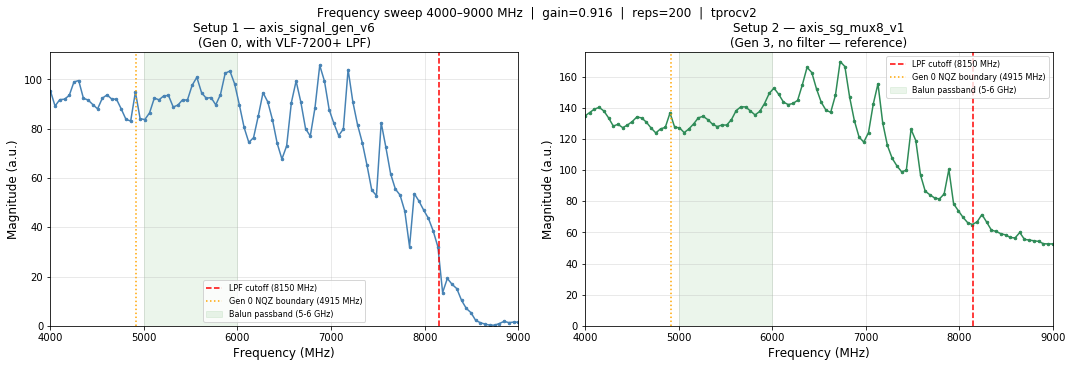

Saved to frequency_sweep_v2_result.png


In [10]:
# ── Plot side by side ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_data = [
    (axes[0], mags1, "Setup 1 — axis_signal_gen_v6\n(Gen 0, with VLF-7200+ LPF)",  "steelblue"),
    (axes[1], mags2, "Setup 2 — axis_sg_mux8_v1\n(Gen 3, no filter — reference)", "seagreen"),
]

for ax, mags, title, color in plot_data:
    ax.plot(actual_freqs, mags, color=color, linewidth=1.5, marker='.', markersize=5)
    ax.axvline(x=8150,    color='red',    linestyle='--', linewidth=1.5, label='LPF cutoff (8150 MHz)')
    ax.axvline(x=soccfg['gens'][GEN_CH_1]['fs']/2,
               color='orange', linestyle=':', linewidth=1.5,
               label=f"Gen 0 NQZ boundary ({soccfg['gens'][GEN_CH_1]['fs']/2:.0f} MHz)")
    ax.axvspan(5000, 6000, alpha=0.08, color='green', label='Balun passband (5-6 GHz)')
    ax.set_xlabel("Frequency (MHz)", fontsize=12)
    ax.set_ylabel("Magnitude (a.u.)", fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(freqs_mhz[0], freqs_mhz[-1])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.35)

plt.suptitle(
    f"Frequency sweep {freqs_mhz[0]:.0f}–{freqs_mhz[-1]:.0f} MHz  |  "
    f"gain={base_config['pulse_gain']:.3f}  |  reps={base_config['reps']}  |  tprocv2",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("frequency_sweep_v2_result.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to frequency_sweep_v2_result.png")

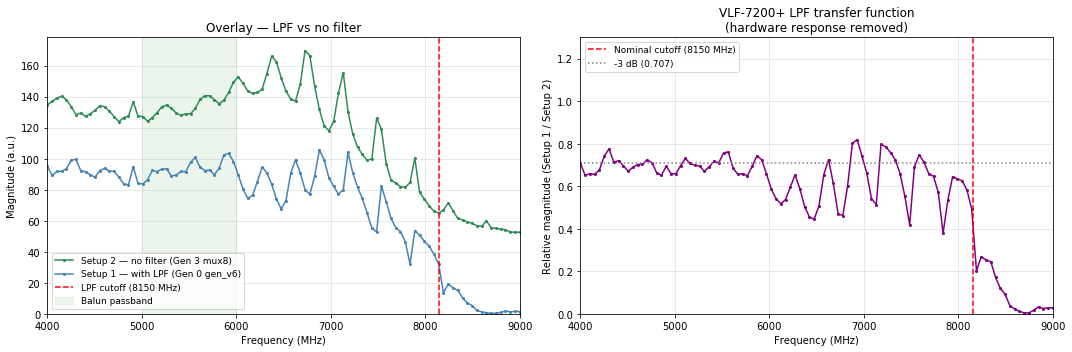

Saved to frequency_sweep_v2_analysis.png


In [11]:
# ── Overlay + filter transfer function ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Overlay plot
ax1.plot(actual_freqs, mags2, color='seagreen',  linewidth=1.5, marker='.', markersize=4,
         label='Setup 2 — no filter (Gen 3 mux8)')
ax1.plot(actual_freqs, mags1, color='steelblue', linewidth=1.5, marker='.', markersize=4,
         label='Setup 1 — with LPF (Gen 0 gen_v6)')
ax1.axvline(x=8150, color='red', linestyle='--', linewidth=1.5, label='LPF cutoff (8150 MHz)')
ax1.axvspan(5000, 6000, alpha=0.08, color='green', label='Balun passband')
ax1.set_xlabel("Frequency (MHz)"); ax1.set_ylabel("Magnitude (a.u.)")
ax1.set_title("Overlay — LPF vs no filter"); ax1.legend(fontsize=9)
ax1.set_xlim(freqs_mhz[0], freqs_mhz[-1]); ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.35)

# Filter transfer function (ratio removes hardware response)
safe_mags2 = np.where(mags2 > 0.1, mags2, np.nan)
filter_tf = mags1 / safe_mags2

ax2.plot(actual_freqs, filter_tf, color='purple', linewidth=1.5, marker='.', markersize=4)
ax2.axvline(x=8150, color='red',  linestyle='--', linewidth=1.5, label='Nominal cutoff (8150 MHz)')
ax2.axhline(y=1/np.sqrt(2), color='gray', linestyle=':', linewidth=1.5, label='-3 dB (0.707)')
ax2.set_xlabel("Frequency (MHz)"); ax2.set_ylabel("Relative magnitude (Setup 1 / Setup 2)")
ax2.set_title("VLF-7200+ LPF transfer function\n(hardware response removed)")
ax2.set_xlim(freqs_mhz[0], freqs_mhz[-1]); ax2.set_ylim(0, 1.3)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig("frequency_sweep_v2_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to frequency_sweep_v2_analysis.png")

## Diagnostic: DDC beat frequency measurement

If the `acquire_decimated` trace shows oscillating I/Q with flat magnitude, the DDC is not tuned to the correct alias frequency. Run this cell to measure the beat frequency and compute a corrected DDC setting.

  0%|          | 0/1 [00:00<?, ?it/s]

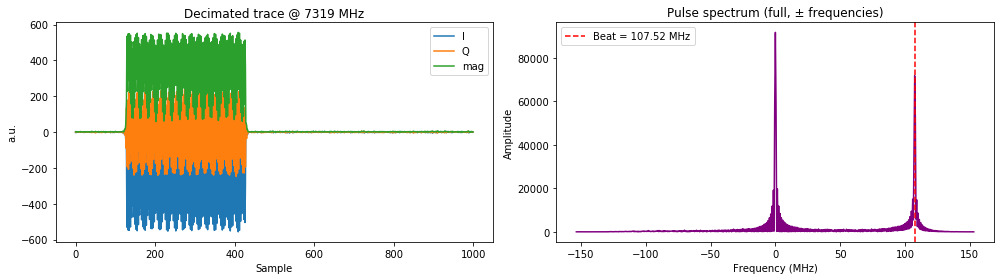

Beat frequency: 107.520 MHz
Current pulse_freq: 7319.000 MHz
If beat != 0, manually set DDC alias to: -53.720 MHz
Then use: self.add_readoutconfig(ch=..., name='ro_cfg', freq=<corrected_alias>)


In [12]:
# ── DDC diagnostic — run if you see IQ oscillations ───────────────────────────
# Acquire a decimated trace and FFT it to find the residual beat frequency

DIAG_FREQ = 7319  # MHz — frequency to diagnose
DIAG_GEN  = GEN_CH_1
DIAG_RO   = RO_CH_1
ProgramClass = Setup1Program  # or Setup2Program

diag_cfg = {
    "res_ch":    DIAG_GEN,
    "ro_chs":    [DIAG_RO],
    "reps":      1,
    "relax_delay": 1.0,
    "res_phase": 0,
    "pulse_gain": 30000 / 32767,
    "pulse_freq": soccfg.adcfreq(DIAG_FREQ, DIAG_GEN, DIAG_RO),
    "length":    soccfg.cycles2us(600, gen_ch=DIAG_GEN),
    "readout_length": soccfg.cycles2us(1000, ro_ch=DIAG_RO),
    "adc_trig_offset": 0.0,
    "rounds": 100,
    "nqz": 2,
}

prog_diag = ProgramClass(soccfg, reps=diag_cfg["reps"],
                         final_delay=diag_cfg["relax_delay"], cfg=diag_cfg)
iq_dec = prog_diag.acquire_decimated(soc)

# iq_dec shape: [n_ro_chs, readout_length, 2]
I_trace = iq_dec[0][:, 0]
Q_trace = iq_dec[0][:, 1]

# Plot the decimated trace
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(I_trace, label='I'); axes[0].plot(Q_trace, label='Q')
axes[0].plot(np.abs(I_trace + 1j*Q_trace), label='mag')
axes[0].set_title(f"Decimated trace @ {DIAG_FREQ} MHz")
axes[0].set_xlabel("Sample"); axes[0].set_ylabel("a.u."); axes[0].legend()

# FFT to find beat frequency
# Focus on the pulse region — adjust indices if needed
pulse_start, pulse_end = 100, 700  # sample indices — adjust to match pulse location
pulse = I_trace[pulse_start:pulse_end] + 1j * Q_trace[pulse_start:pulse_end]
fs_dec = soccfg['readouts'][DIAG_RO]['f_fabric']  # MHz
freqs_fft = np.fft.fftshift(np.fft.fftfreq(len(pulse), d=1/fs_dec))
spectrum  = np.abs(np.fft.fftshift(np.fft.fft(pulse)))

# Mask DC and find peak
dc_bin = len(freqs_fft) // 2
spec_no_dc = spectrum.copy()
spec_no_dc[dc_bin-3:dc_bin+3] = 0
beat_freq = freqs_fft[np.argmax(spec_no_dc)]

axes[1].plot(freqs_fft, spectrum, color='purple')
axes[1].axvline(x=beat_freq, color='red', linestyle='--', label=f'Beat = {beat_freq:.2f} MHz')
axes[1].set_title("Pulse spectrum (full, ± frequencies)")
axes[1].set_xlabel("Frequency (MHz)"); axes[1].set_ylabel("Amplitude")
axes[1].legend(); plt.tight_layout(); plt.show()

print(f"Beat frequency: {beat_freq:.3f} MHz")
print(f"Current pulse_freq: {diag_cfg['pulse_freq']:.3f} MHz")
print(f"If beat != 0, manually set DDC alias to: {53.8 - beat_freq:.3f} MHz")
print("Then use: self.add_readoutconfig(ch=..., name='ro_cfg', freq=<corrected_alias>)")